# AIRBNB BERLÍN — MODELADO PREDICTIVO DE PRECIOS
---

## 1. IMPORTAR LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## 2. CARGAR DATASET

In [2]:
df = pd.read_csv('listings_features.csv')
print(f'Shape original: {df.shape}')
df.head(3)

Shape original: (7173, 27)


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,id,name,latitude,longitude,minimum_nights,amenities,last_review,...,review_scores_location,review_scores_checkin,log_price,price_per_person,price_per_bedroom,neighbourhood_median_price,neighbourhood_price_rank,amenities_count,days_since_last_review,is_entire_home
0,0,0,0,3176,Fabulous Flat in great Location,52.53471,13.41810,63,"[""Cooking basics"", ""Wine glasses"", ""Crib"", ""Ho...",2025-08-09,...,4.92,4.65,4.663439,52.500000,105.00,150.0,128,44,45,1
1,1,1,1,9991,Geourgeous flat - outstanding views,52.53269,13.41805,6,"[""Cooking basics"", ""Crib"", ""Stove"", ""Elevator""...",2020-01-04,...,4.86,5.00,4.912655,19.285714,33.75,150.0,128,32,2089,1
2,2,2,2,14325,Studio Apartment in Prenzlauer Berg,52.54813,13.40366,150,"[""Ethernet connection"", ""Dishes and silverware...",2023-11-30,...,4.60,4.70,4.330733,75.000000,NaN,103.5,87,14,663,1


## 3. PREPARACIÓN DE DATOS
---

### 3.1 Eliminar columnas innecesarias

Las columnas `Unnamed` son índices acumulados de exportaciones anteriores del CSV.
Las columnas `id`, `host_id`, `name`, `amenities` y `last_review` no son features del modelo.

In [3]:
cols_drop = [
    'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2',
    'id', 'host_id', 'name',
    'amenities', 'last_review',
    # Estas están derivadas del precio — usarlas sería hacer trampa
    'price_per_person', 'price_per_bedroom',
    # log_price es la variable objetivo alternativa, no una feature
    'log_price'
]

# Eliminar solo las que existan en el dataset
cols_drop = [c for c in cols_drop if c in df.columns]
df = df.drop(columns=cols_drop)

print(f'Shape tras limpieza: {df.shape}')
print(f'Columnas restantes: {list(df.columns)}')

Shape tras limpieza: (7173, 16)
Columnas restantes: ['latitude', 'longitude', 'minimum_nights', 'room_type', 'price', 'neighbourhood_cleansed', 'bedrooms', 'accommodates', 'review_scores_rating', 'review_scores_location', 'review_scores_checkin', 'neighbourhood_median_price', 'neighbourhood_price_rank', 'amenities_count', 'days_since_last_review', 'is_entire_home']


### 3.2 Tratar nulos en price_per_bedroom

Los 501 nulos corresponden a pisos con bedrooms = 0 (estudios).
Se imputa con la mediana — es la estrategia más robusta ante outliers.

In [4]:
print(f'Nulos antes: {df.isnull().sum().sum()}')
df.isnull().sum()[df.isnull().sum() > 0]

Nulos antes: 0


Series([], dtype: int64)

### 3.3 Encoding de variables categóricas

`room_type` y `neighbourhood_cleansed` son strings — los modelos necesitan números.

- `room_type`: pocos valores únicos → One-Hot Encoding
- `neighbourhood_cleansed`: alta cardinalidad → ya tenemos `neighbourhood_median_price` y `neighbourhood_price_rank` como encoding numérico, así que la eliminamos directamente

In [5]:
print('Valores únicos room_type:')
print(df['room_type'].value_counts())

Valores únicos room_type:
room_type
Entire home/apt    5180
Private room       1824
Hotel room           90
Shared room          79
Name: count, dtype: int64


In [6]:
# One-Hot Encoding de room_type
df = pd.get_dummies(df, columns=['room_type'], drop_first=True)

# Eliminar neighbourhood_cleansed — ya está codificado numéricamente
df = df.drop(columns=['neighbourhood_cleansed'])

# Eliminar coordenadas — no son features del modelo de precios
df = df.drop(columns=['latitude', 'longitude'], errors='ignore')

print(f'Shape final: {df.shape}')
print(f'Columnas: {list(df.columns)}')

Shape final: (7173, 15)
Columnas: ['minimum_nights', 'price', 'bedrooms', 'accommodates', 'review_scores_rating', 'review_scores_location', 'review_scores_checkin', 'neighbourhood_median_price', 'neighbourhood_price_rank', 'amenities_count', 'days_since_last_review', 'is_entire_home', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


### 3.4 Definir features y variable objetivo

In [7]:
TARGET = 'price'

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'\nVariable objetivo: {TARGET}')
print(f'\nDistribución del target:')
print(y.describe().round(2))

Features (14): ['minimum_nights', 'bedrooms', 'accommodates', 'review_scores_rating', 'review_scores_location', 'review_scores_checkin', 'neighbourhood_median_price', 'neighbourhood_price_rank', 'amenities_count', 'days_since_last_review', 'is_entire_home', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']

Variable objetivo: price

Distribución del target:
count     7173.00
mean       173.15
std       1221.91
min          5.00
25%         73.00
50%        110.00
75%        166.00
max      50000.00
Name: price, dtype: float64


### 3.5 Train / Test split

80% entrenamiento, 20% test. `random_state=42` para reproducibilidad.

In [8]:
# Eliminar outliers extremos de precio
# Por encima de 500€ hay valores anómalos que distorsionan el entrenamiento
precio_limite = 500
df = df[df["price"] <= precio_limite].reset_index(drop=True)

print(f"Registros tras eliminar outliers: {df.shape[0]}")
print(f"Precio máximo ahora: {df["price"].max()}€")
print(df["price"].describe().round(2))

# Redefinir X e y tras el filtro
X = df[FEATURES]
y = df[TARGET]

Registros tras eliminar outliers: 7094
Precio máximo ahora: 500.0€
count    7094.00
mean      129.22
std        77.96
min         5.00
25%        73.00
50%       109.00
75%       163.00
max       500.00
Name: price, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} registros')
print(f'Test:  {X_test.shape[0]} registros')

Train: 5675 registros
Test:  1419 registros


### 3.6 Escalado para regresión lineal

Solo necesario para el modelo lineal — Random Forest y XGBoost son invariantes a la escala.
Se ajusta el scaler SOLO con train para no filtrar información del test al modelo.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 4. FUNCIÓN DE EVALUACIÓN
---

Centraliza las métricas para poder comparar todos los modelos de forma consistente.

In [11]:
resultados = {}

def evaluar_modelo(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)

    resultados[nombre] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R²': round(r2, 4)}

    print(f'--- {nombre} ---')
    print(f'  RMSE : {rmse:.2f} €')
    print(f'  MAE  : {mae:.2f} €')
    print(f'  R²   : {r2:.4f}')
    print()

    return y_pred

## 5. MODELOS
---

### 5.1 Regresión Lineal (baseline)

Punto de partida. Modelo simple que establece el rendimiento mínimo esperado.
Usa datos escalados y `log_price` como target para cumplir los supuestos del modelo lineal.
Las predicciones se re-exponencian para evaluar en euros reales.

In [12]:
# Target en escala logarítmica para regresión lineal
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)

# Predicción en log → re-exponenciar a euros
y_pred_lr_log = lr.predict(X_test_scaled)
y_pred_lr = np.expm1(y_pred_lr_log)

pred_lr = evaluar_modelo('Regresión Lineal', y_test, y_pred_lr)

--- Regresión Lineal ---
  RMSE : 53.26 €
  MAE  : 35.79 €
  R²   : 0.4974



### 5.2 Random Forest

Modelo principal. Conjunto de árboles de decisión robusto ante outliers y no-linealidades.
No necesita escalado ni transformación logarítmica.

In [13]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
pred_rf = evaluar_modelo('Random Forest', y_test, y_pred_rf)

--- Random Forest ---
  RMSE : 47.15 €
  MAE  : 32.96 €
  R²   : 0.6062



In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 15],
    'min_samples_leaf': [2, 3, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f'Mejores parámetros: {grid_rf.best_params_}')

y_pred_grid = grid_rf.predict(X_test)
evaluar_modelo('Random Forest (GridSearch)', y_test, y_pred_grid)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
--- Random Forest (GridSearch) ---
  RMSE : 47.39 €
  MAE  : 33.16 €
  R²   : 0.6021



array([ 78.56354752, 197.46854327, 150.89517952, ...,  76.54234433,
       104.15745272, 249.94223341], shape=(1419,))

### 5.3 XGBoost

Gradient boosting — construye árboles secuencialmente corrigiendo los errores del anterior.
Suele ser el modelo con mejor rendimiento en datasets tabulares.

In [15]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
pred_xgb = evaluar_modelo('XGBoost', y_test, y_pred_xgb)

--- XGBoost ---
  RMSE : 46.94 €
  MAE  : 32.69 €
  R²   : 0.6095



## 5.3 Logaritmo para xgboost

In [16]:
# XGBoost con log_price como target
y_train_log = np.log1p(y_train)

xgb_log = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_log.fit(X_train, y_train_log)

# Re-exponenciar para evaluar en euros reales
y_pred_xgb_log = np.expm1(xgb_log.predict(X_test))
evaluar_modelo('XGBoost + log_price', y_test, y_pred_xgb_log)

--- XGBoost + log_price ---
  RMSE : 46.67 €
  MAE  : 31.18 €
  R²   : 0.6141



array([ 76.50883, 213.9395 , 140.45418, ...,  72.98646,  97.16202,
       242.67592], shape=(1419,), dtype=float32)

## 6. COMPARATIVA DE MODELOS
---

In [17]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values('RMSE')
print('Comparativa de modelos (ordenado por RMSE):')
print(df_resultados)

Comparativa de modelos (ordenado por RMSE):
                             RMSE    MAE      R²
XGBoost + log_price         46.67  31.18  0.6141
XGBoost                     46.94  32.69  0.6095
Random Forest               47.15  32.96  0.6062
Random Forest (GridSearch)  47.39  33.16  0.6021
Regresión Lineal            53.26  35.79  0.4974


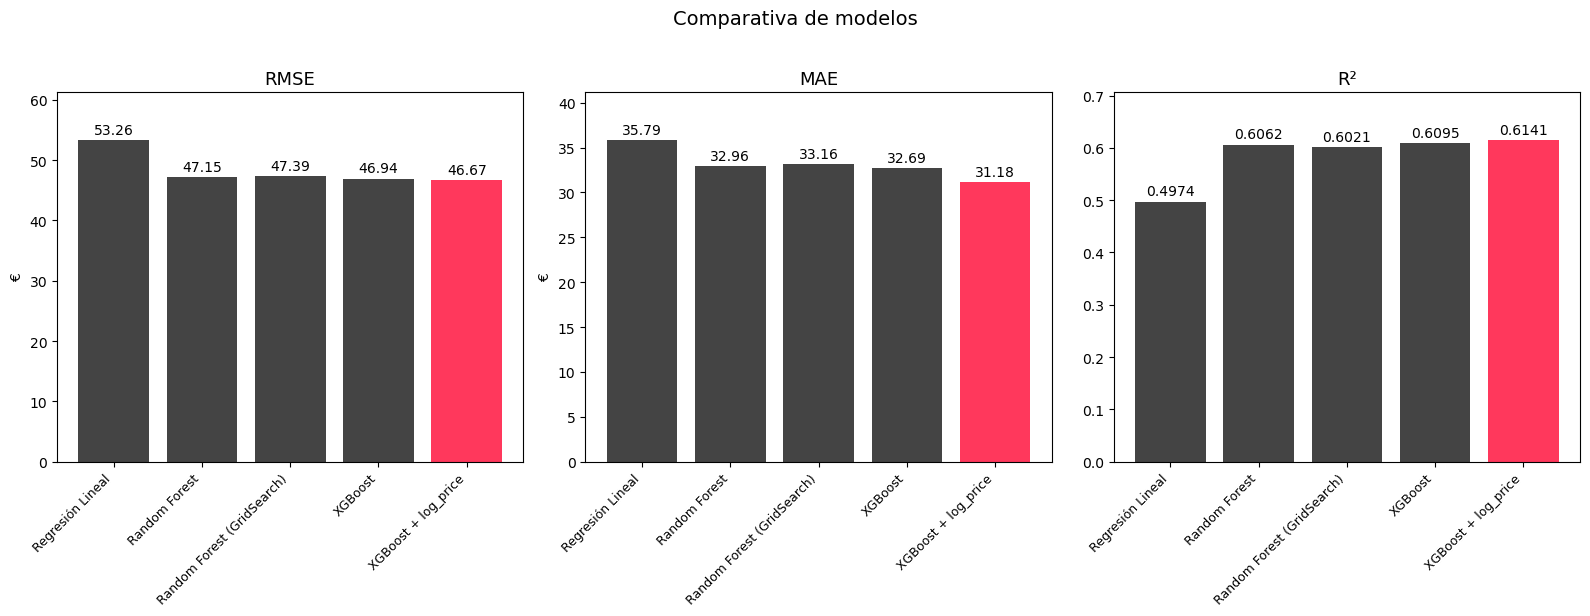

Gráfico guardado como comparativa_modelos.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
modelos = list(resultados.keys())

colores = ['#FF385C' if m == 'XGBoost + log_price' else '#444444' for m in modelos]

for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R²']):
    valores = [resultados[m][metrica] for m in modelos]
    bars = ax.bar(modelos, valores, color=colores)
    ax.set_title(metrica, fontsize=13)
    ax.set_ylabel('€' if metrica != 'R²' else '')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(valores)*0.01,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(valores) * 1.15)
    ax.set_xticklabels(modelos, rotation=45, ha='right', fontsize=9)

plt.suptitle('Comparativa de modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como comparativa_modelos.png')

## 7. ANÁLISIS DEL MEJOR MODELO
---

### 7.1 Predicciones vs valores reales

Mejor modelo: XGBoost + log_price


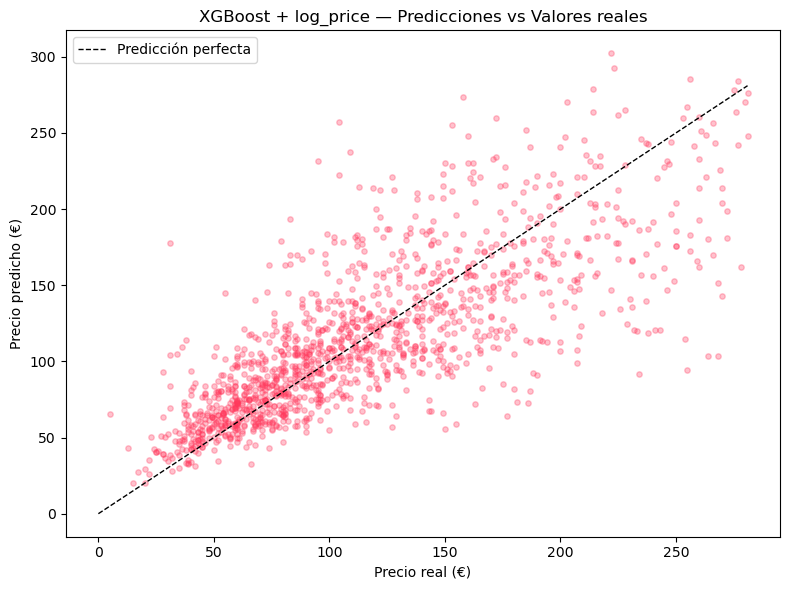

Gráfico guardado como predicciones_vs_real.png


In [19]:
# Usar el mejor modelo (ajusta si Regresión Lineal gana)
mejor_modelo_nombre = df_resultados.index[0]
predicciones_map = {
    'Regresión Lineal': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'XGBoost + log_price': y_pred_xgb_log
}
y_pred_mejor = predicciones_map[mejor_modelo_nombre]

print(f'Mejor modelo: {mejor_modelo_nombre}')

# Filtrar outliers extremos para visualizar mejor
mask = y_test <= y_test.quantile(0.95)

plt.figure(figsize=(8, 6))
plt.scatter(y_test[mask], y_pred_mejor[mask], alpha=0.3, color='#FF385C', s=15)
lims = [0, y_test[mask].max()]
plt.plot(lims, lims, 'k--', linewidth=1, label='Predicción perfecta')
plt.xlabel('Precio real (€)')
plt.ylabel('Precio predicho (€)')
plt.title(f'{mejor_modelo_nombre} — Predicciones vs Valores reales')
plt.legend()
plt.tight_layout()
plt.savefig('predicciones_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como predicciones_vs_real.png')

### 7.2 Importancia de variables (Random Forest y XGBoost)

Muestra qué factores determinan realmente el precio de un alojamiento en Berlín.

importancia_variables.csv exportado


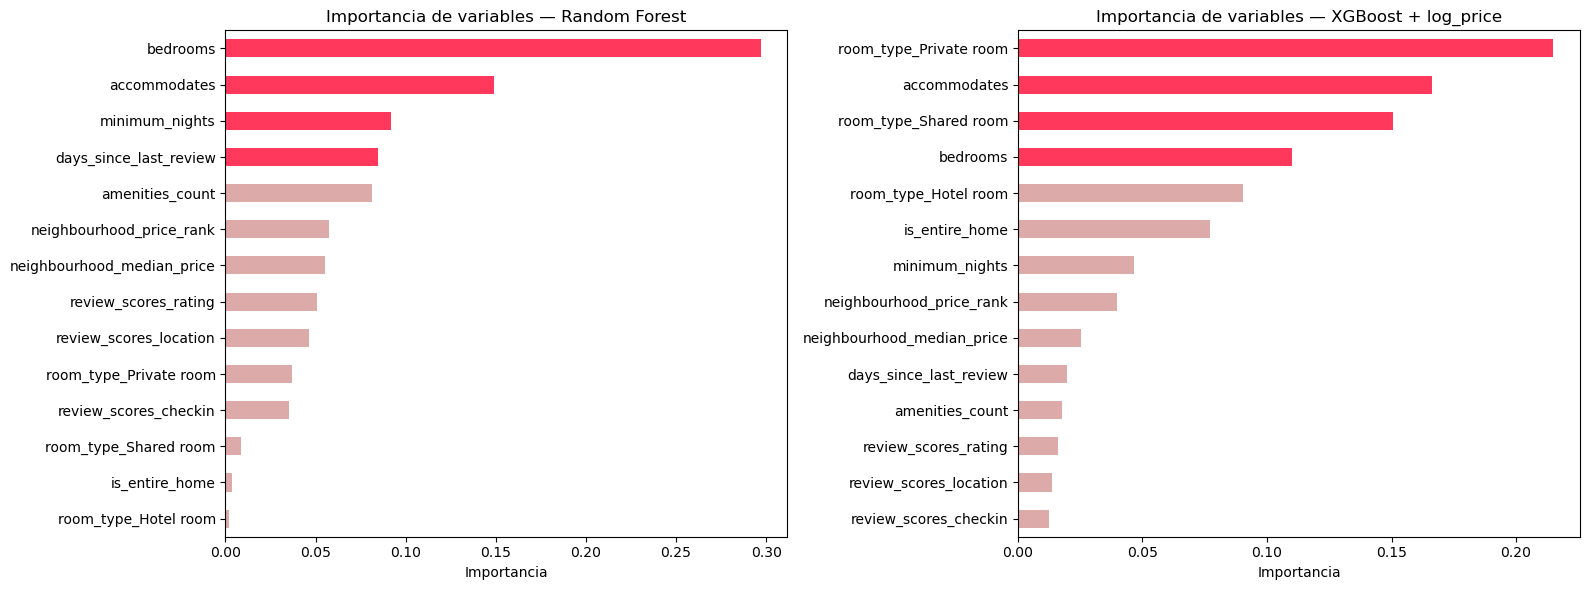

Gráfico guardado como importancia_variables.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Importancia Random Forest
importancias_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_rf = ['#FF385C' if v >= importancias_rf.quantile(0.75) else '#DDAAAA' for v in importancias_rf.values]
importancias_rf.plot(kind='barh', color=colors_rf, ax=axes[0])
axes[0].set_title('Importancia de variables — Random Forest')
axes[0].set_xlabel('Importancia')

# Importancia XGBoost
# Importancia XGBoost
importancias_xgb = pd.Series(xgb_log.feature_importances_, index=FEATURES)
importancias_xgb.sort_values(ascending=False).to_frame('importancia').to_csv(
    'importancia_variables.csv', decimal=',', sep=';'
)

# Dibujar en axes[1]
importancias_xgb_sorted = importancias_xgb.sort_values(ascending=True)
colors_xgb = ['#FF385C' if v >= importancias_xgb_sorted.quantile(0.75) else '#DDAAAA' for v in importancias_xgb_sorted.values]
importancias_xgb_sorted.plot(kind='barh', color=colors_xgb, ax=axes[1])
axes[1].set_title('Importancia de variables — XGBoost + log_price')
axes[1].set_xlabel('Importancia')
print('importancia_variables.csv exportado')

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado como importancia_variables.png')

### 7.3 Distribución de errores

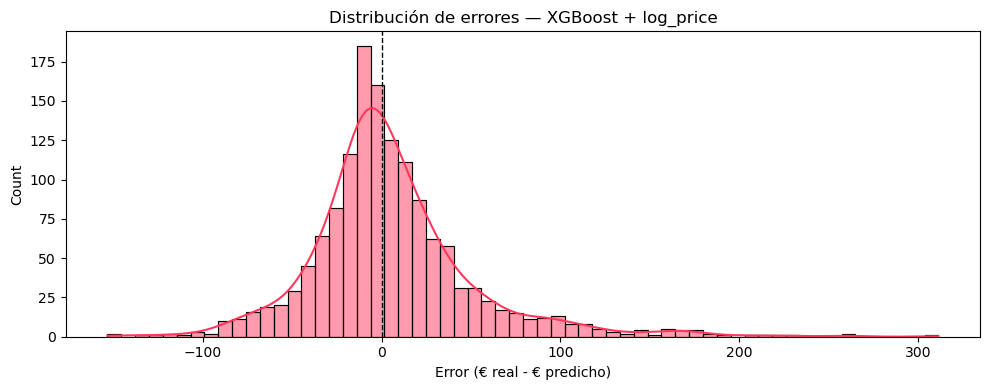

Error medio        : 5.27 €
Error mediano      : -1.46 €
% predicciones     
  con error < 20€  : 50.7%
  con error < 50€  : 81.3%


In [21]:
errores = y_test - y_pred_mejor

plt.figure(figsize=(10, 4))
sns.histplot(errores, bins=60, color='#FF385C', kde=True)
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Error (€ real - € predicho)')
plt.title(f'Distribución de errores — {mejor_modelo_nombre}')
plt.tight_layout()
plt.savefig('distribucion_errores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Error medio        : {errores.mean():.2f} €')
print(f'Error mediano      : {errores.median():.2f} €')
print(f'% predicciones     ')
print(f'  con error < 20€  : {(abs(errores) < 20).mean():.1%}')
print(f'  con error < 50€  : {(abs(errores) < 50).mean():.1%}')

## 8. EXPORTAR RESULTADOS PARA POWER BI
---

Se exportan los CSVs listos para importar directamente en Power BI.

In [26]:
# 1. Tabla de métricas comparativas
df_resultados.to_csv('metricas_modelos.csv', decimal=',', sep=';')

# 2. Predicciones vs real del mejor modelo
df_predicciones = pd.DataFrame({
    'modelo': ['Regresión Lineal'] * len(y_test) +
              ['Random Forest'] * len(y_test) +
              ['Random Forest (GridSearch)'] * len(y_test) +
              ['XGBoost'] * len(y_test) +
              ['XGBoost + log_price'] * len(y_test),
    'precio_real': list(y_test.values) * 5,
    'precio_predicho': list(y_pred_lr) + list(y_pred_rf) + 
                       list(y_pred_grid) + list(y_pred_xgb) + 
                       list(y_pred_xgb_log)
})
df_predicciones.to_csv('predicciones_vs_real.csv', index=False, decimal=',', sep=';')
print(f'Exportado: {df_predicciones.shape[0]} filas')

# 3. Importancia de variables
importancias_xgb.sort_values(ascending=False).to_frame('importancia').to_csv(
    'importancia_variables.csv', decimal=',', sep=';'
)
print('importancia_variables.csv exportado')

# 4. Comparativa todos los modelos
# 4. Comparativa todos los modelos
df_export = df_resultados.copy()
df_export.index.name = 'Modelo'
df_export.to_csv('comparativa_modelos.csv', decimal=',', sep=';')
print('comparativa_modelos.csv exportado')

Exportado: 7095 filas
importancia_variables.csv exportado
comparativa_modelos.csv exportado


In [23]:
df_mapa = pd.read_csv('listings_features.csv')
df_mapa = df_mapa[df_mapa['price'] <= 500]
df_mapa = df_mapa[['neighbourhood_cleansed', 'latitude', 'longitude',
                    'price', 'room_type', 'accommodates', 'bedrooms',
                    'neighbourhood_median_price', 'amenities_count',
                    'review_scores_rating']]

df_mapa.to_csv('airbnb_berlin_mapa.csv', index=False, decimal=',', sep=';')
print(f'Exportado: airbnb_berlin_mapa.csv — {df_mapa.shape[0]} registros')

Exportado: airbnb_berlin_mapa.csv — 7094 registros


In [24]:
df_check = pd.read_csv('listings_features.csv')
print(df_check[['latitude', 'longitude']].head(10))
print()
print(df_check['latitude'].dtype)

   latitude  longitude
0  52.53471   13.41810
1  52.53269   13.41805
2  52.54813   13.40366
3  52.49419   13.42166
4  52.53711   13.40888
5  52.53355   13.40476
6  52.49134   13.37975
7  52.54419   13.41956
8  52.54804   13.40349
9  52.54596   13.42291

float64


## 9. RESUMEN FINAL
---

In [25]:
print('=' * 50)
print('RESUMEN DEL PROYECTO')
print('=' * 50)
print(f'Dataset            : {df.shape[0]} alojamientos, {len(FEATURES)} features')
print(f'Train / Test       : {X_train.shape[0]} / {X_test.shape[0]} registros')
print()
print('Resultados:')
print(df_resultados.to_string())
print()
print(f'Mejor modelo       : {mejor_modelo_nombre}')
print(f'RMSE               : {resultados[mejor_modelo_nombre]["RMSE"]} €')
print(f'MAE                : {resultados[mejor_modelo_nombre]["MAE"]} €')
print(f'R²                 : {resultados[mejor_modelo_nombre]["R²"]}')
print()
print('Archivos exportados para Power BI:')
print('  - metricas_modelos.csv')
print('  - predicciones_vs_real.csv')
print('  - importancia_variables.csv')
print('  - comparativa_modelos.png')
print('  - importancia_variables.png')
print('  - predicciones_vs_real.png')

RESUMEN DEL PROYECTO
Dataset            : 7094 alojamientos, 14 features
Train / Test       : 5675 / 1419 registros

Resultados:
                             RMSE    MAE      R²
XGBoost + log_price         46.67  31.18  0.6141
XGBoost                     46.94  32.69  0.6095
Random Forest               47.15  32.96  0.6062
Random Forest (GridSearch)  47.39  33.16  0.6021
Regresión Lineal            53.26  35.79  0.4974

Mejor modelo       : XGBoost + log_price
RMSE               : 46.67 €
MAE                : 31.18 €
R²                 : 0.6141

Archivos exportados para Power BI:
  - metricas_modelos.csv
  - predicciones_vs_real.csv
  - importancia_variables.csv
  - comparativa_modelos.png
  - importancia_variables.png
  - predicciones_vs_real.png
